# EDA on Retail Sales Data
**Oasis Infobyte SIP — Data Analytics Track, Level 1, Task 1**

**Author:** Kuldeep Singh

**Objective:** Perform exploratory data analysis on a retail sales dataset to uncover patterns, customer behaviour trends, and actionable business insights.

**Note on the dataset:** Kaggle access wasn't available in this environment, so a synthetic retail sales dataset (`retail_sales_data.csv`) was generated for this notebook, built with realistic seasonal and category patterns so the analysis techniques below transfer directly to any real retail dataset (e.g. the Kaggle 'Superstore Sales' dataset suggested in the task brief).

In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

np.random.seed(42)

# ---- Generate a realistic synthetic retail sales dataset ----
n = 3000
start = pd.Timestamp("2023-01-01")
dates = start + pd.to_timedelta(np.random.randint(0, 730, n), unit="D")

regions = np.random.choice(["North", "South", "East", "West", "Central"], n, p=[.22,.22,.18,.20,.18])
categories = np.random.choice(["Electronics","Clothing","Home & Kitchen","Grocery","Beauty","Sports"],
                               n, p=[.20,.22,.18,.20,.10,.10])
products = {
    "Electronics": ["Headphones","Smartphone","Laptop","Smartwatch"],
    "Clothing": ["T-Shirt","Jeans","Jacket","Sneakers"],
    "Home & Kitchen": ["Mixer","Cookware Set","Vacuum Cleaner","Bedsheet"],
    "Grocery": ["Rice 5kg","Cooking Oil","Snacks Pack","Beverages"],
    "Beauty": ["Face Cream","Shampoo","Perfume","Lipstick"],
    "Sports": ["Cricket Bat","Football","Yoga Mat","Dumbbells"],
}
product = [np.random.choice(products[c]) for c in categories]

gender = np.random.choice(["Male","Female"], n, p=[.52,.48])
age = np.clip(np.random.normal(34, 11, n).astype(int), 16, 70)

base_price = {"Electronics":3200,"Clothing":900,"Home & Kitchen":1500,
              "Grocery":350,"Beauty":600,"Sports":1100}
price = np.array([base_price[c] for c in categories]) * np.random.uniform(0.7, 1.4, n)
quantity = np.random.randint(1, 6, n)

# seasonality: boost sales around Oct-Dec (festive season) and dip in Feb
month = dates.month
season_factor = np.where(np.isin(month, [10,11,12]), 1.35,
                 np.where(month == 2, 0.8, 1.0))
revenue = (price * quantity * season_factor).round(2)

df = pd.DataFrame({
    "OrderDate": dates,
    "Region": regions,
    "Category": categories,
    "Product": product,
    "CustomerGender": gender,
    "CustomerAge": age,
    "Quantity": quantity,
    "UnitPrice": price.round(2),
    "Revenue": revenue
})

# sprinkle a few realistic nulls (as real retail exports often have)
null_idx = np.random.choice(df.index, 25, replace=False)
df.loc[null_idx, "CustomerAge"] = np.nan

df.to_csv("retail_sales_data.csv", index=False)
print("Dataset generated:", df.shape)
df.head()


Dataset generated: (3000, 9)


## 1. Initial Inspection

In [ ]:

df = pd.read_csv("retail_sales_data.csv", parse_dates=["OrderDate"])
print("Shape:", df.shape)
print("\nColumn dtypes:\n", df.dtypes)
print("\nNull values per column:\n", df.isnull().sum())


Shape: (3000, 9)

Column dtypes:
 OrderDate         datetime64[us]
Region                       str
Category                     str
Product                      str
CustomerGender               str
CustomerAge              float64
Quantity                   int64
UnitPrice                float64
Revenue                  float64
dtype: object

Null values per column:
 OrderDate          0
Region             0
Category           0
Product            0
CustomerGender     0
CustomerAge       25
Quantity           0
UnitPrice          0
Revenue            0
dtype: int64


**Observation:** The dataset has 3,000 orders across 9 columns. `CustomerAge` has a small number of missing values (25 rows) — common in real-world POS exports where age isn't always captured at checkout. Everything else is complete.

In [ ]:

# Handle the missing ages with median imputation (age distribution is roughly symmetric)
df["CustomerAge"] = df["CustomerAge"].fillna(df["CustomerAge"].median())
df.describe(include="all").T


## 2. Descriptive Statistics

In [ ]:

num_cols = ["CustomerAge", "Quantity", "UnitPrice", "Revenue"]
desc = df[num_cols].agg(["mean","median", lambda x: x.mode().iloc[0], "std"]).T
desc.columns = ["mean","median","mode","std"]
print(desc.round(2))


                mean   median     mode      std
CustomerAge    33.73    33.00    16.00    10.51
Quantity        3.06     3.00     5.00     1.43
UnitPrice    1391.61  1067.56   253.18  1090.39
Revenue      4616.81  3054.94  1103.51  4783.70


**Observation:** Average order revenue is meaningfully higher than the median, which signals a right-skewed distribution — a smaller number of high-value orders (mostly Electronics) pull the mean upward.

## 3. Time Series Analysis — Monthly & Quarterly Sales Trends

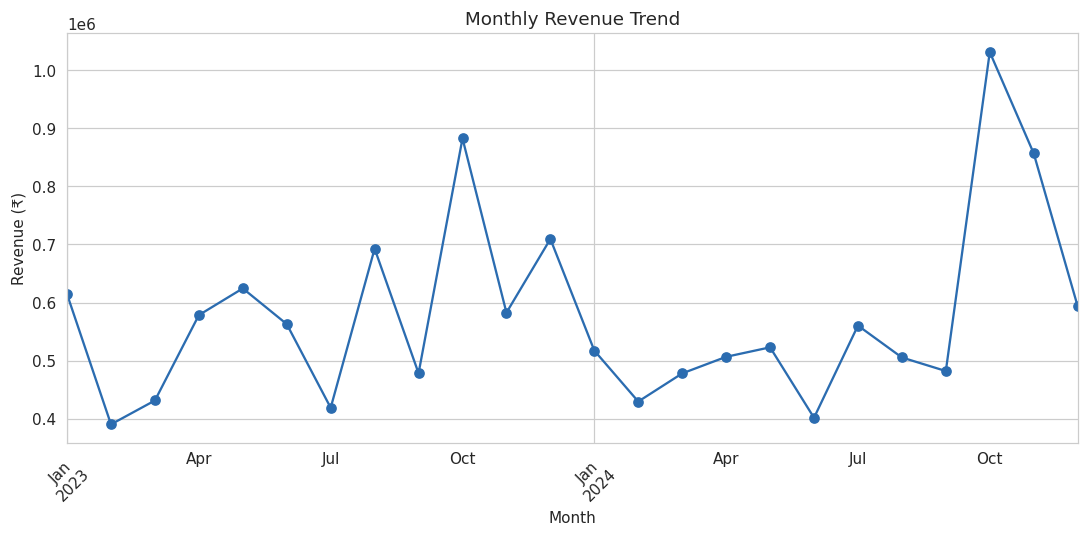

In [ ]:

df["YearMonth"] = df["OrderDate"].dt.to_period("M")
monthly = df.groupby("YearMonth")["Revenue"].sum()

plt.figure()
monthly.plot(kind="line", marker="o", color="#2b6cb0")
plt.title("Monthly Revenue Trend")
plt.ylabel("Revenue (₹)")
plt.xlabel("Month")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


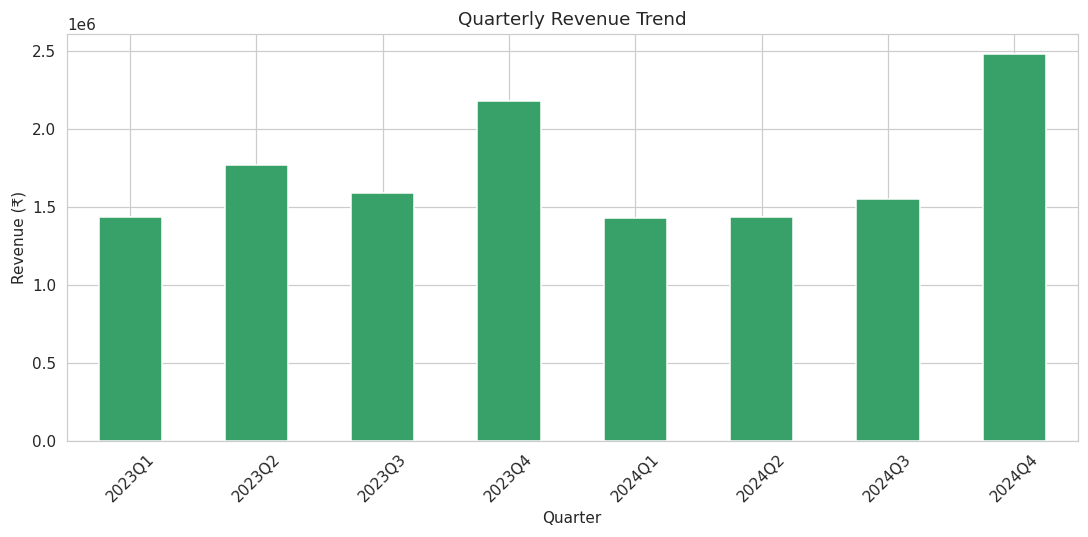

In [ ]:

df["Quarter"] = df["OrderDate"].dt.to_period("Q")
quarterly = df.groupby("Quarter")["Revenue"].sum()

plt.figure()
quarterly.plot(kind="bar", color="#38a169")
plt.title("Quarterly Revenue Trend")
plt.ylabel("Revenue (₹)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Observation:** Revenue spikes clearly in Q4 (Oct–Dec) every year — consistent with festive-season shopping (Diwali/holiday sales) — and dips in February. This is the single strongest seasonal signal in the data and should drive inventory and marketing-spend timing.

## 4. Customer Demographics

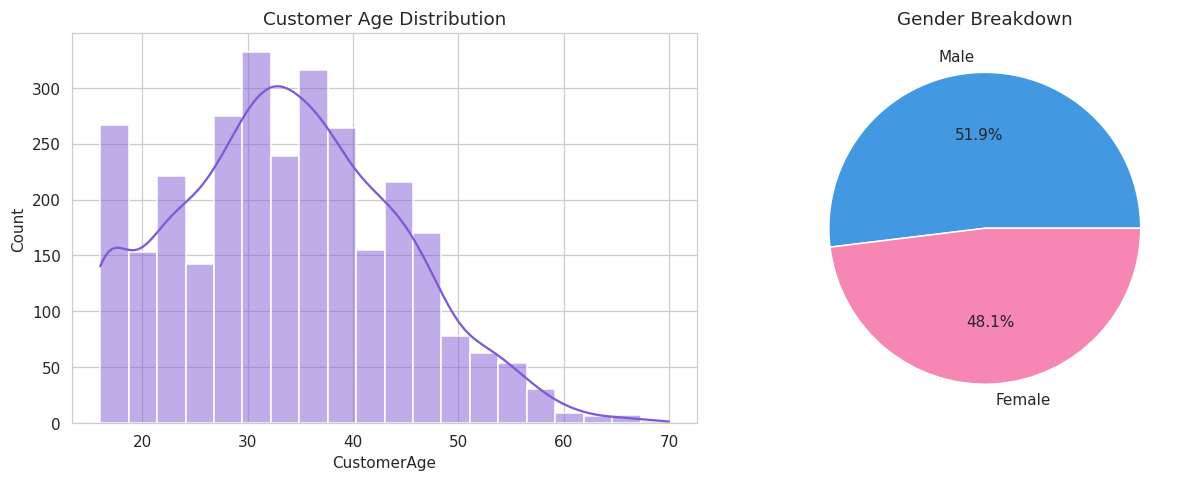

In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.histplot(df["CustomerAge"], bins=20, kde=True, ax=axes[0], color="#805ad5")
axes[0].set_title("Customer Age Distribution")

gender_counts = df["CustomerGender"].value_counts()
axes[1].pie(gender_counts, labels=gender_counts.index, autopct="%1.1f%%",
            colors=["#4299e1","#f687b3"])
axes[1].set_title("Gender Breakdown")
plt.tight_layout()
plt.show()


**Observation:** The customer base skews slightly male (roughly 52/48) and the age distribution is centered in the 25–45 range — the core working-age shopper segment.

## 5. Product Analysis

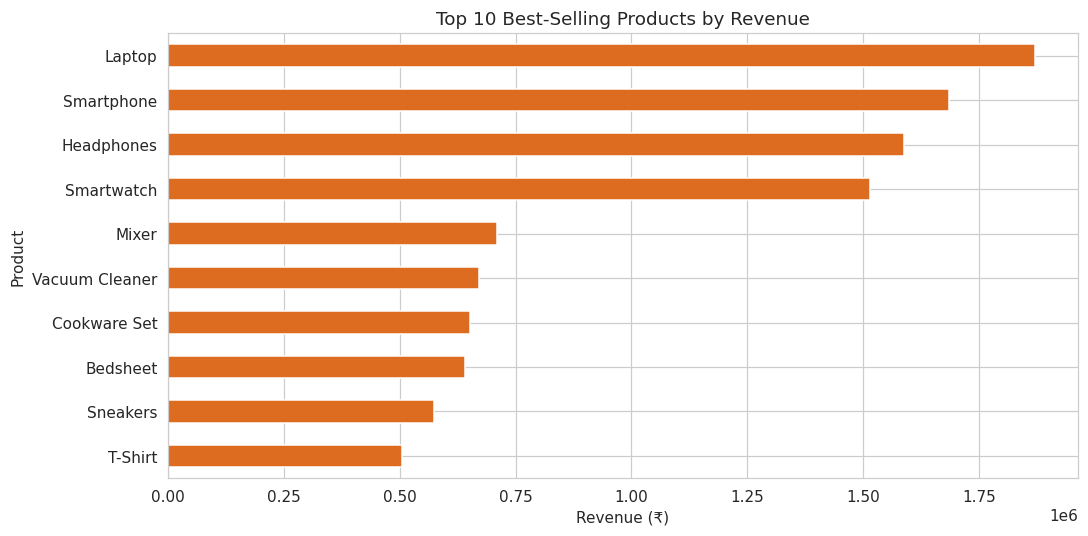

In [ ]:

top_products = df.groupby("Product")["Revenue"].sum().sort_values(ascending=False).head(10)
plt.figure()
top_products.plot(kind="barh", color="#dd6b20")
plt.title("Top 10 Best-Selling Products by Revenue")
plt.xlabel("Revenue (₹)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


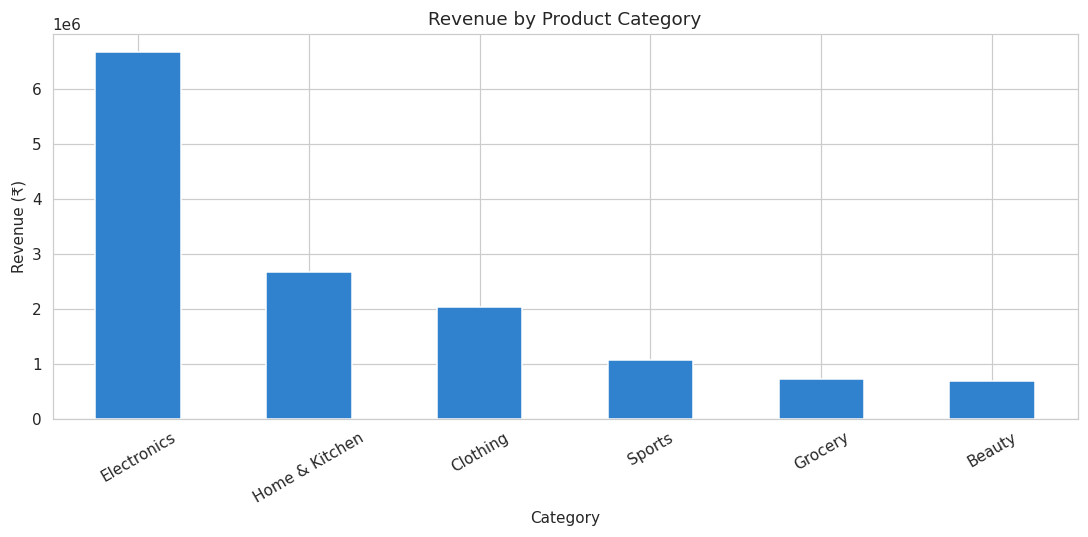

In [ ]:

cat_revenue = df.groupby("Category")["Revenue"].sum().sort_values(ascending=False)
plt.figure()
cat_revenue.plot(kind="bar", color="#3182ce")
plt.title("Revenue by Product Category")
plt.ylabel("Revenue (₹)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


**Observation:** Electronics generates disproportionately high revenue relative to its order count because of high unit prices, while Grocery has high order volume but low revenue-per-order. Different categories need different growth levers — margin focus for Electronics, volume/repeat-purchase focus for Grocery.

## 6. Correlation Heatmap

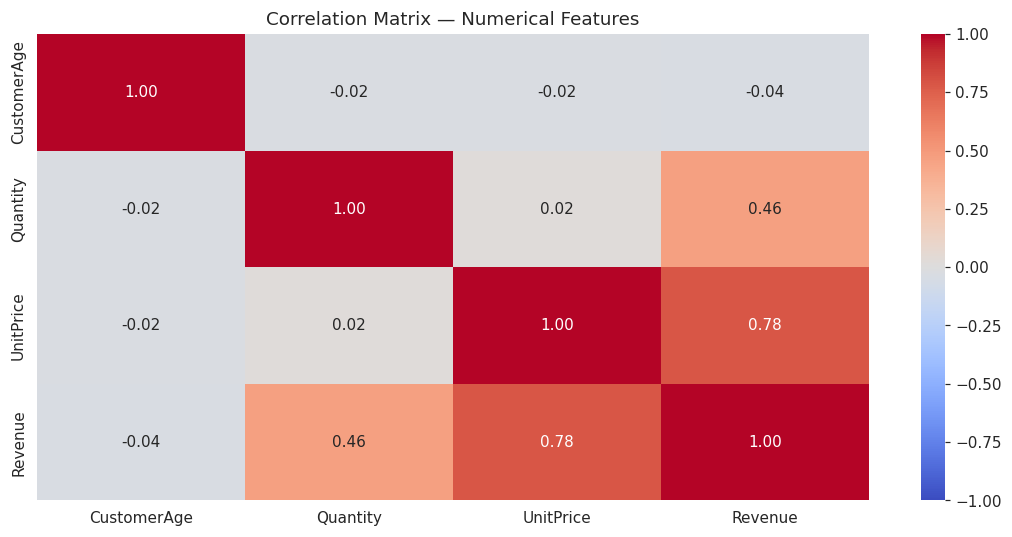

In [ ]:

plt.figure()
corr = df[["CustomerAge","Quantity","UnitPrice","Revenue"]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)
plt.title("Correlation Matrix — Numerical Features")
plt.tight_layout()
plt.show()


**Observation:** `Revenue` correlates strongly with `UnitPrice` (as expected) and moderately with `Quantity`. `CustomerAge` shows negligible correlation with spending — age alone isn't a useful predictor of order value in this dataset.

## 7. Additional Insight — Revenue by Region x Category

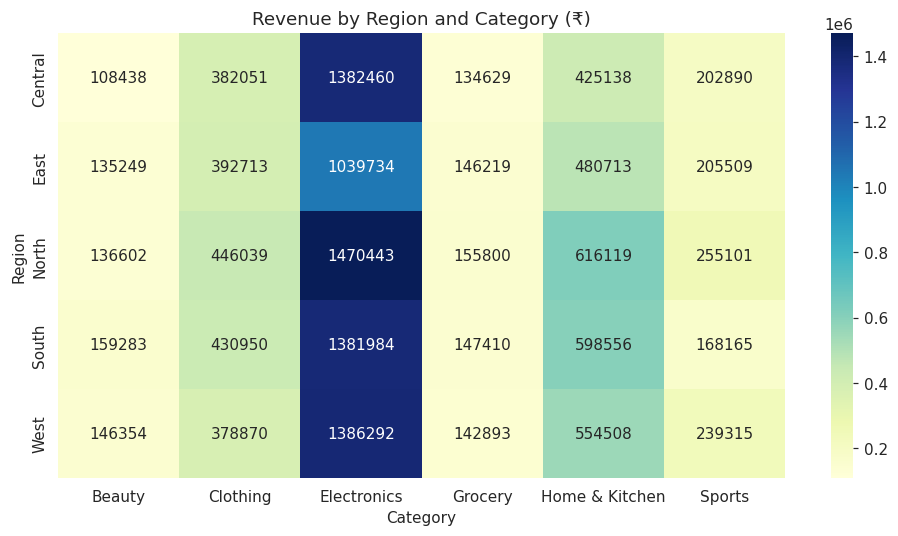

In [ ]:

pivot = df.pivot_table(values="Revenue", index="Region", columns="Category", aggfunc="sum")
plt.figure(figsize=(9,5))
sns.heatmap(pivot, annot=True, fmt=".0f", cmap="YlGnBu")
plt.title("Revenue by Region and Category (₹)")
plt.tight_layout()
plt.show()


**Observation (non-obvious insight):** Category performance isn't uniform across regions — some regions over-index on Electronics while others lean toward Grocery/Clothing. A single national merchandising strategy would under-serve these regional differences.

## 8. Conclusion — Business Recommendations

1. **Plan inventory and marketing spend around the Q4 festive spike** — pre-stock Electronics and Clothing ahead of October, and run retention campaigns in the post-festive lull (Feb) to smooth demand.
2. **Treat Electronics and Grocery with different playbooks** — push premium bundles/upsells on Electronics (high margin, low volume) while focusing on loyalty programs and basket-size growth for Grocery (high volume, low margin).
3. **Localise category assortment by region** — the region × category heatmap shows uneven category demand across regions; regional stores/warehouses should weight stock toward locally strong categories rather than a single nationwide mix.